# Анализ данных и подготовка признаков — Предсказание выкупа заказов

**Задача:** по данным AmoCRM предсказать, выкупит ли клиент заказ (binary classification: `buyout_flag`).

**Контекст:** интернет-магазин отправляет заказы наложенным платежом. Часть клиентов не забирает товар — это приводит к расходам на доставку и возврат. Цель — определить до отправки, будет ли заказ выкуплен.

**Ключевой инсайт:** повторные клиенты (`contact_Число сделок >= 1`) выкупают в 97%+ случаев — для них достаточно модели на одном признаке. Основная сложность — новые клиенты (buyout ~32%), для которых используется LogReg на ~25 признаках.

Этот ноутбук выполняет:
1. Загрузку и очистку данных
2. Разведочный анализ (EDA) — визуализация каждого признака и его связи с целевой переменной
3. Feature engineering — создание информативных признаков
4. Разделение на train/test/val (60/20/20) отдельно для новых и повторных клиентов
5. Сохранение подготовленных данных для ноутбука обучения

In [1]:
import pandas as pd
import numpy as np
import json
import os
import pickle
import warnings
import calendar
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 200)

## 1. Загрузка и очистка данных

Датасет содержит записи о заказах из AmoCRM за период март 2025 — март 2026. Каждая строка — одна сделка (lead) с информацией о клиенте, товаре, доставке и статусе.

Очистка:
- Убираем строки с `outcome_unknown == True` — сделки, по которым исход ещё неизвестен
- Приводим `buyout_flag` к бинарному формату (0/1)
- Конвертируем типы столбцов (даты, числа)

In [2]:
DATA_PATH = 'dataset_2025-03-01_2026-03-29_external.csv'
if not os.path.exists(DATA_PATH):
    DATA_PATH = '../dataset_2025-03-01_2026-03-29_external.csv'

df_raw = pd.read_csv(DATA_PATH, low_memory=False)
print(f"Загружено строк: {len(df_raw)}")

# Убираем строки с неизвестным исходом
df = df_raw[df_raw['outcome_unknown'] == False].copy()
print(f"С известным исходом: {len(df)}")

# Целевая переменная
df['buyout_flag'] = df['buyout_flag'].map(
    {'True': 1, 'true': 1, True: 1, 'False': 0, 'false': 0, False: 0}
).astype(int)

# Приведение типов
df['sale_ts'] = pd.to_numeric(df['sale_ts'], errors='coerce')
df['lead_created_at'] = pd.to_numeric(df['lead_created_at'], errors='coerce')
df['sale_date'] = pd.to_datetime(df['sale_date'], errors='coerce')
df['lead_price'] = pd.to_numeric(df['lead_price'], errors='coerce')
df['contact_Число сделок'] = pd.to_numeric(df.get('contact_Число сделок'), errors='coerce')

for col in ['lead_Вес (грамм)*', 'lead_Длина', 'lead_Ширина', 'lead_Высота',
             'lead_Скидка', 'lead_Стоимость доставки']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

buyout_rate = df['buyout_flag'].mean()
print(f"\nBuyout rate: {buyout_rate:.4f} ({buyout_rate*100:.1f}%)")
print(f"Выкуп: {df['buyout_flag'].sum()}, Отказ: {(1 - df['buyout_flag']).sum()}")

Загружено строк: 18887
С известным исходом: 17966

Buyout rate: 0.8283 (82.8%)
Выкуп: 14882, Отказ: 3084


## 2. Общий обзор данных

Прежде чем строить модель, изучим распределение целевой переменной и основные характеристики двух ключевых групп клиентов:
- **Новые клиенты** (`contact_Число сделок` = NaN или 0) — первый заказ, buyout ~32%
- **Повторные клиенты** (`contact_Число сделок` >= 1) — уже заказывали ранее, buyout 97%+

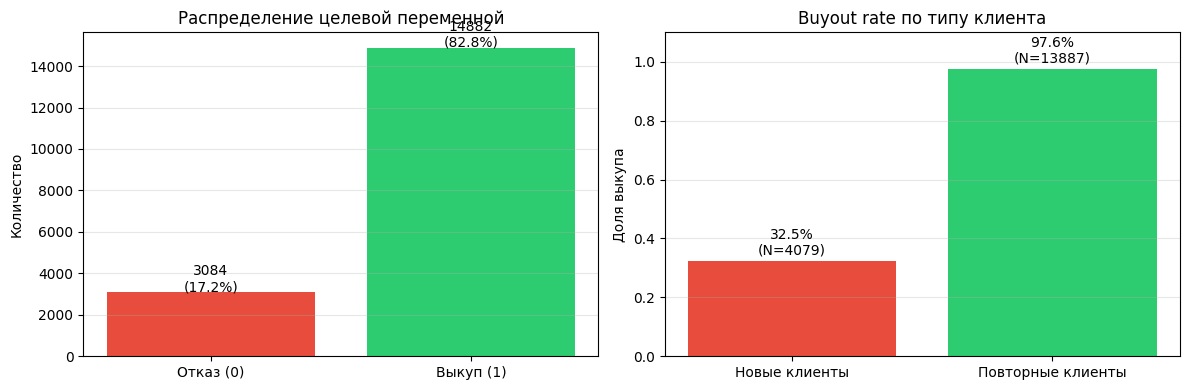

Всего строк: 17966
Новые клиенты: 4079 (22.7%), buyout: 0.3248
Повторные:     13887 (77.3%), buyout: 0.9762


In [3]:
GREEN = '#2ecc71'
RED = '#e74c3c'

# Баланс классов
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['buyout_flag'].value_counts().sort_index()
axes[0].bar(['Отказ (0)', 'Выкуп (1)'], counts.values, color=[RED, GREEN])
axes[0].set_title('Распределение целевой переменной')
axes[0].set_ylabel('Количество')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, f'{v}\n({v/len(df)*100:.1f}%)', ha='center')
axes[0].grid(axis='y', alpha=0.3)

# Новые vs повторные
is_new = df['contact_Число сделок'].isna() | (df['contact_Число сделок'] < 1)
groups = pd.DataFrame({
    'type': ['Новые клиенты', 'Повторные клиенты'],
    'count': [is_new.sum(), (~is_new).sum()],
    'buyout_rate': [df.loc[is_new, 'buyout_flag'].mean(), df.loc[~is_new, 'buyout_flag'].mean()]
})

bars = axes[1].bar(groups['type'], groups['buyout_rate'], color=[RED, GREEN])
axes[1].set_title('Buyout rate по типу клиента')
axes[1].set_ylabel('Доля выкупа')
axes[1].set_ylim(0, 1.1)
for bar, rate, cnt in zip(bars, groups['buyout_rate'], groups['count']):
    axes[1].text(bar.get_x() + bar.get_width()/2, rate + 0.02,
                 f'{rate:.1%}\n(N={cnt})', ha='center')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout(); plt.show()

print(f"Всего строк: {len(df)}")
print(f"Новые клиенты: {is_new.sum()} ({is_new.mean()*100:.1f}%), buyout: {df.loc[is_new, 'buyout_flag'].mean():.4f}")
print(f"Повторные:     {(~is_new).sum()} ({(~is_new).mean()*100:.1f}%), buyout: {df.loc[~is_new, 'buyout_flag'].mean():.4f}")

## 3. EDA — Категориальные признаки

Для каждого категориального признака строим двухпанельный график:
- **Верхняя панель:** количество выкупов и отказов (side-by-side bars)
- **Нижняя панель:** доля выкупа/отказа в каждой категории (stacked 100% bars)

Это позволяет одновременно видеть как частоту категорий, так и их влияние на целевую переменную.

In [4]:
LEAD_QUAL_ORDER = ['А - лид', 'В - лид', 'С - лид', 'D - лид', 'Е - лид', 'Неквал лид']

def _ordered_categories(col, counts_index, n_tot):
    """Порядок меток: месяц/день/квартал — по номеру; квалификация — по рангу; иначе по количеству."""
    idx_set = set(counts_index)
    def by_total_desc(keys):
        return sorted(keys, key=lambda x: -int(n_tot.loc[x]))

    if col == 'sale_month':
        nums = sorted([x for x in idx_set if str(x).isdigit()], key=lambda x: int(x))
        rest = [x for x in idx_set if not str(x).isdigit()]
        return nums + by_total_desc(rest)

    if col == 'sale_weekday':
        nums = sorted([x for x in idx_set if str(x).isdigit()], key=lambda x: int(x))
        rest = [x for x in idx_set if not str(x).isdigit()]
        return nums + by_total_desc(rest)

    if col == 'sale_quarter':
        nums = sorted([x for x in idx_set if str(x).isdigit()], key=lambda x: int(x))
        rest = [x for x in idx_set if not str(x).isdigit()]
        return nums + by_total_desc(rest)

    if col == 'lead_Квалификация лида':
        order = [q for q in LEAD_QUAL_ORDER if q in idx_set]
        rest = [x for x in idx_set if x not in order]
        return order + by_total_desc(rest)

    return by_total_desc(list(idx_set))


def plot_feature_two_panel(df, col, title, top_n=None):
    """Категориальный признак: верх — count bars, низ — stacked 100% bars."""
    work = df
    if top_n is not None:
        keep = df[col].value_counts().head(top_n).index
        work = df.loc[df[col].isin(keep)]
    g = work.groupby(col, observed=True)['buyout_flag']
    n_buy = g.sum()
    n_tot = g.count()
    n_cancel = n_tot - n_buy
    rate = (n_buy / n_tot.replace(0, np.nan)).fillna(0.0)

    order = _ordered_categories(col, n_buy.index, n_tot)
    n_buy = n_buy.reindex(order, fill_value=0)
    n_cancel = n_cancel.reindex(order, fill_value=0)
    rate = rate.reindex(order, fill_value=0)

    labels = [str(x) for x in order]
    x = np.arange(len(labels))
    w = 0.36

    _fw, _fh = (14, 9) if top_n is not None else (11, 8)
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(_fw, _fh), sharex=True)
    fig.suptitle(title, fontsize=13)

    ax1.bar(x - w/2, n_buy.values, width=w, color=GREEN, label='Выкуп (продажи)')
    ax1.bar(x + w/2, n_cancel.values, width=w, color=RED, label='Отмена (без выкупа)')
    ax1.set_ylabel('Количество')
    ax1.legend(loc='center right')
    ax1.grid(axis='y', alpha=0.3)

    ax2.bar(x, rate.values, color=GREEN, label='Доля выкупа')
    ax2.bar(x, 1.0 - rate.values, bottom=rate.values, color=RED, label='Доля отмен')
    ax2.set_ylabel('Доля')
    ax2.set_ylim(0, 1)
    ax2.legend(loc='center right')
    ax2.set_xticks(x)
    ax2.set_xticklabels(labels, rotation=45, ha='right')
    ax2.grid(axis='y', alpha=0.3)

    tbl = pd.DataFrame({
        'выкуп': n_buy.astype(int).values,
        'без_выкупа': n_cancel.astype(int).values,
        'всего': (n_buy + n_cancel).astype(int).values,
        'buyout_rate': rate.values,
    }, index=labels)
    tbl.index.name = col
    print(f"\n{'=' * 60}\n{title}\n{'=' * 60}")
    print(tbl.to_string(float_format='%.3f'))

    plt.tight_layout(); plt.show()

print('Функции визуализации определены')

Функции визуализации определены



lead_Служба доставки
                      выкуп  без_выкупа  всего  buyout_rate
lead_Служба доставки                                       
СДЭК до ПВЗ           10663        1925  12588        0.847
Почта                  2235         687   2922        0.765
СДЭК до Двери          1960         456   2416        0.811
Самовывоз                21           2     23        0.913
Курьер ЕМС                1           1      2        0.500


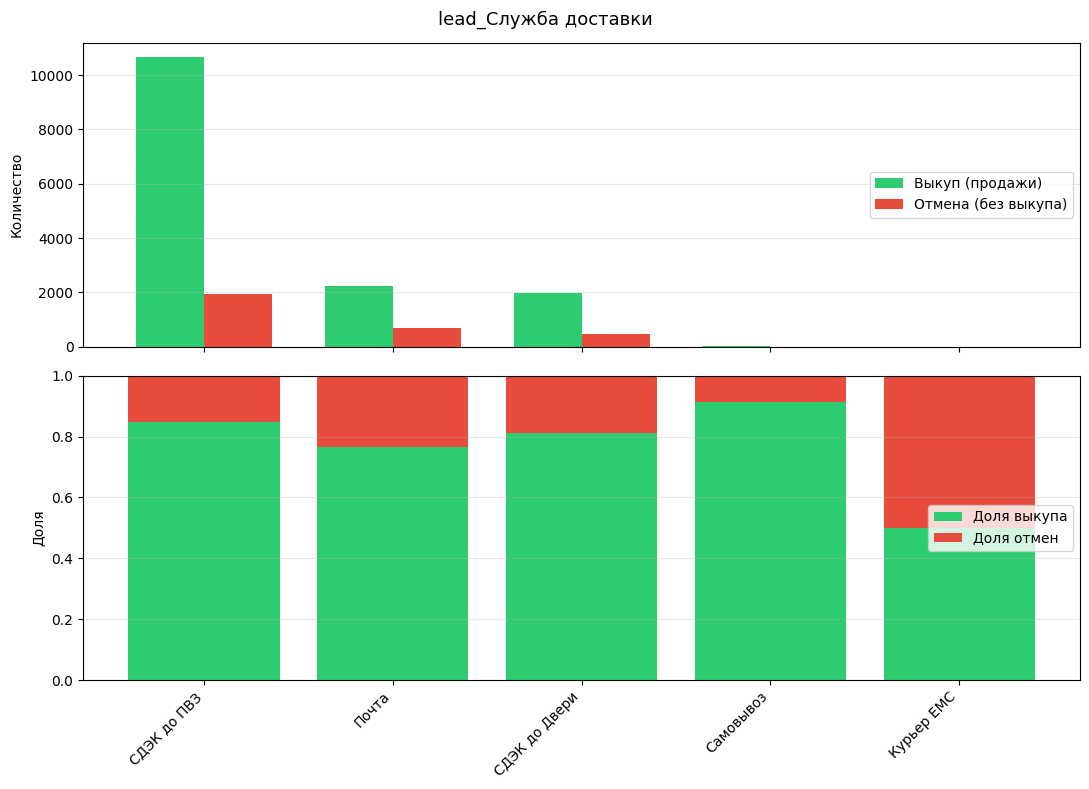


lead_Вид оплаты
                        выкуп  без_выкупа  всего  buyout_rate
lead_Вид оплаты                                              
Наложенный платеж       14125        3050  17175        0.822
Оплата онлайн             577          14    591        0.976
Оплата на карту           170           4    174        0.977
Оплата Золотой Короной      3           1      4        0.750


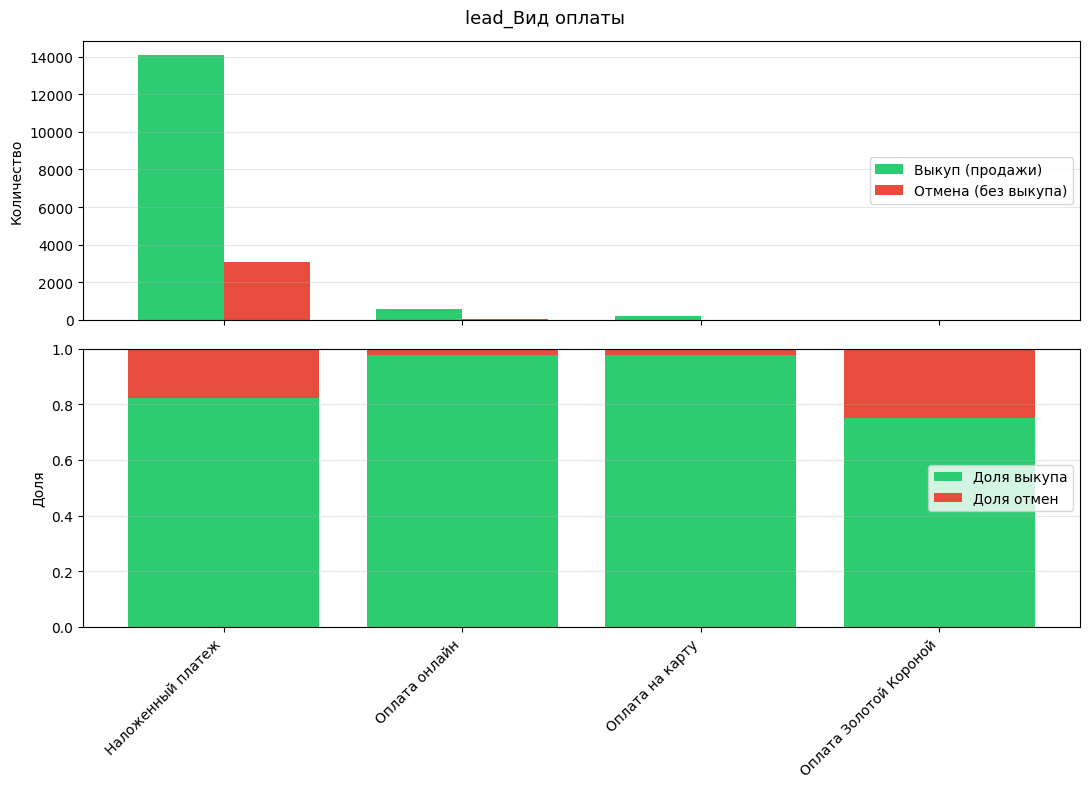


lead_Компания Отправитель
                           выкуп  без_выкупа  всего  buyout_rate
lead_Компания Отправитель                                       
ООО ТехПродЗдрав           14631        3036  17667        0.828
ООО Здоров                   245          34    279        0.878


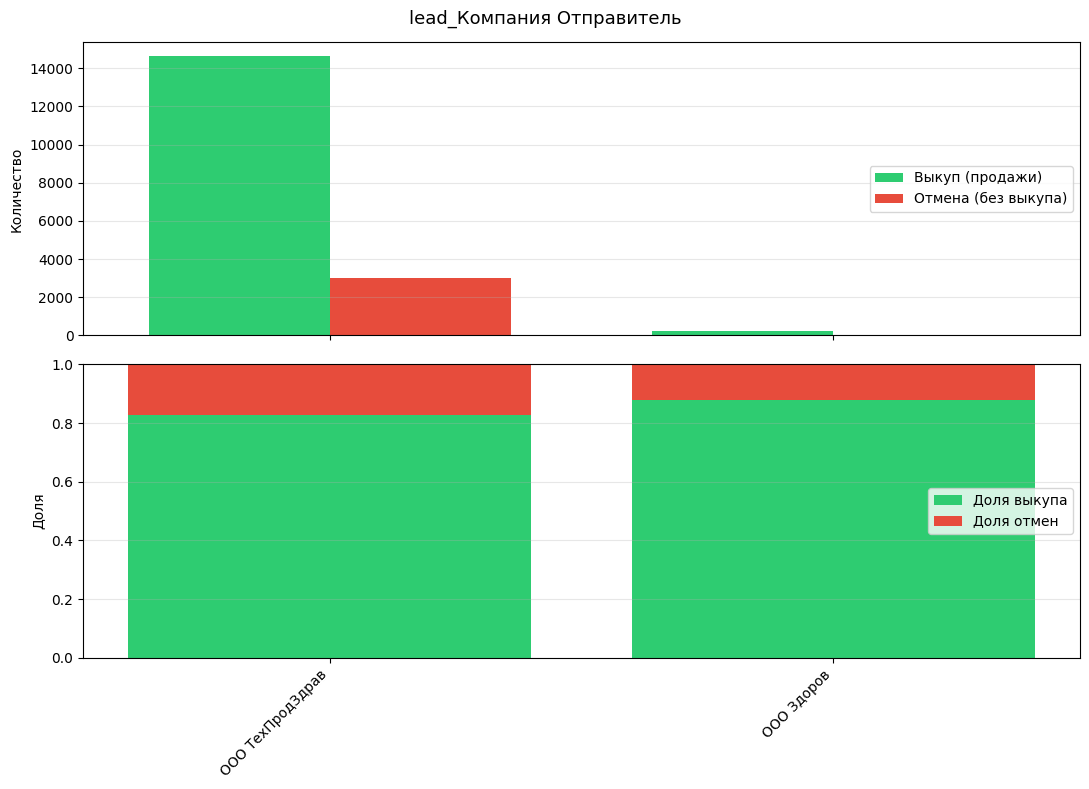


lead_Тариф Доставки
                                 выкуп  без_выкупа  всего  buyout_rate
lead_Тариф Доставки                                                   
Посылка склад-склад              10551        2060  12611        0.837
Посылка склад-дверь               1855         448   2303        0.805
Почта Посылка                     1357         406   1763        0.770
Экономичная посылка склад-склад     94          27    121        0.777
Почта Посылка 1 класса              35          12     47        0.745
Экономичная посылка склад-дверь     18           8     26        0.692
Экспресс склад-склад                 8           1      9        0.889
Экспресс склад-дверь                 2           1      3        0.667
Посылка склад-постамат               2           0      2        1.000


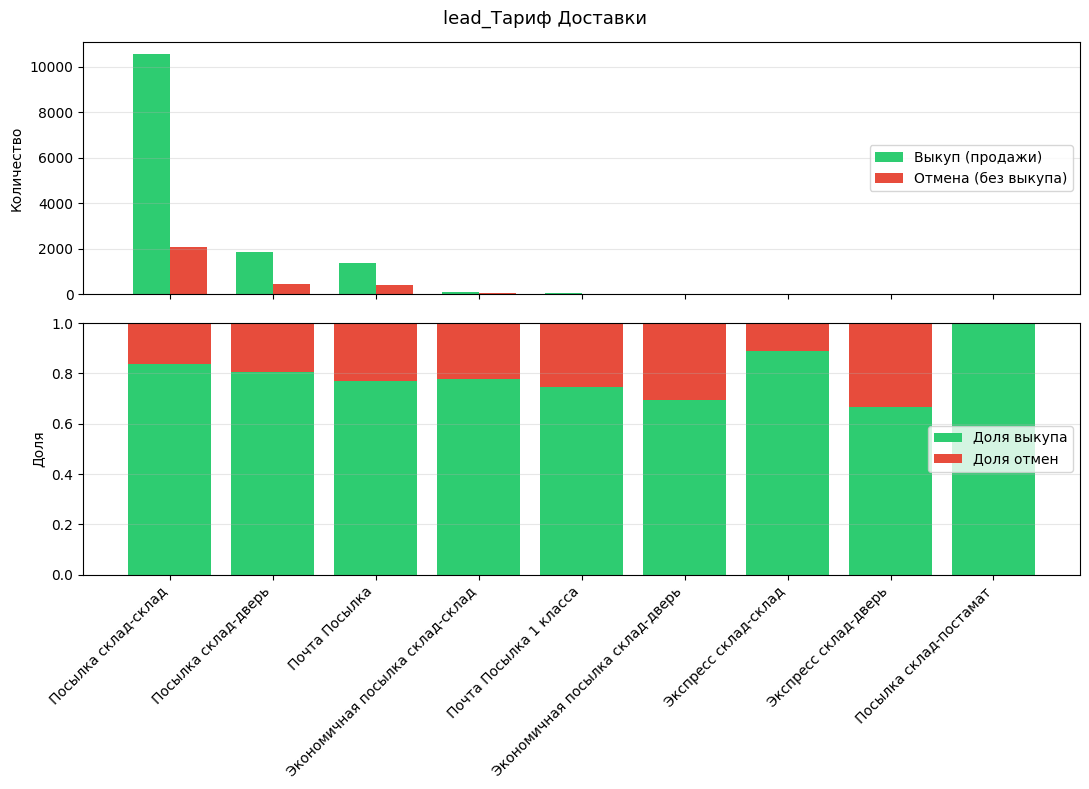


lead_Квалификация лида
                        выкуп  без_выкупа  всего  buyout_rate
lead_Квалификация лида                                       
А - лид                  5244         991   6235        0.841
В - лид                  2455         686   3141        0.782
С - лид                  1395         441   1836        0.760
D - лид                    10          10     20        0.500
Е - лид                     3           0      3        1.000
Неквал лид                139          36    175        0.794


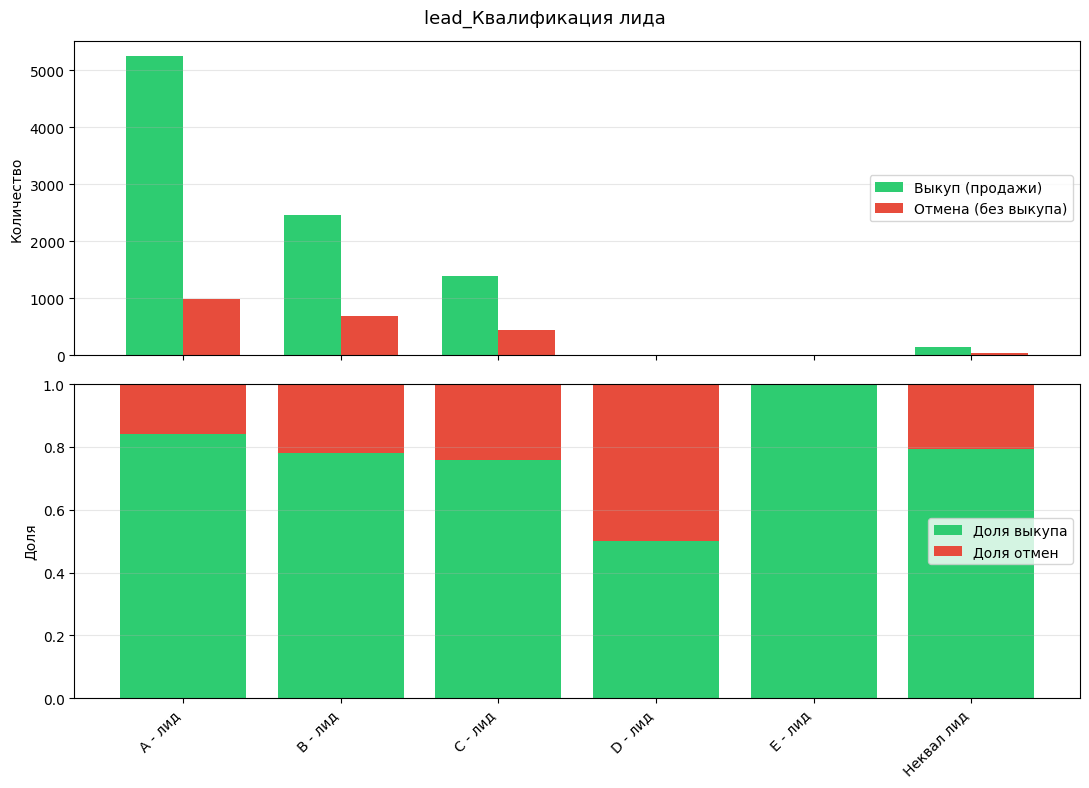


lead_Категория и варианты выбора
                                  выкуп  без_выкупа  всего  buyout_rate
lead_Категория и варианты выбора                                       
S                                  4152         924   5076        0.818
I                                  1678         477   2155        0.779
D                                   983         210   1193        0.824
C                                   255          66    321        0.794
Нет категории                       147          39    186        0.790


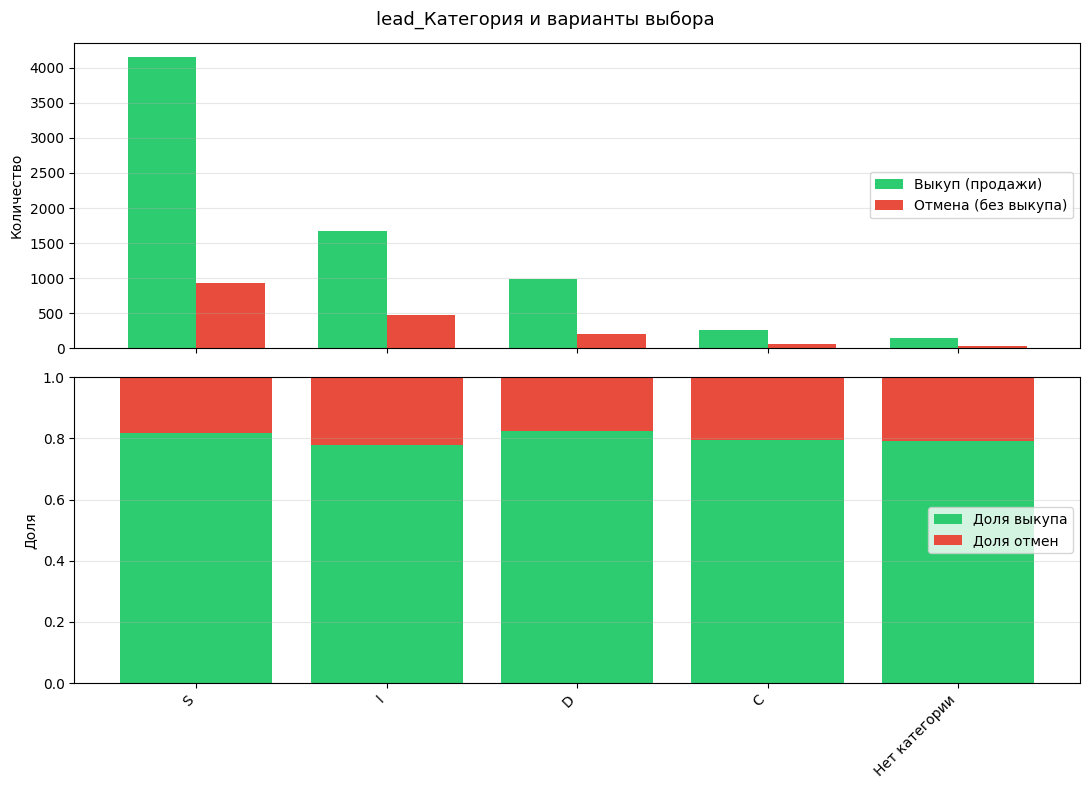


lead_Модель телефона
                      выкуп  без_выкупа  всего  buyout_rate
lead_Модель телефона                                       
Смартфон               6107        1325   7432        0.822
Не удалось узнать      4316        1012   5328        0.810
Кнопочный               199          60    259        0.768


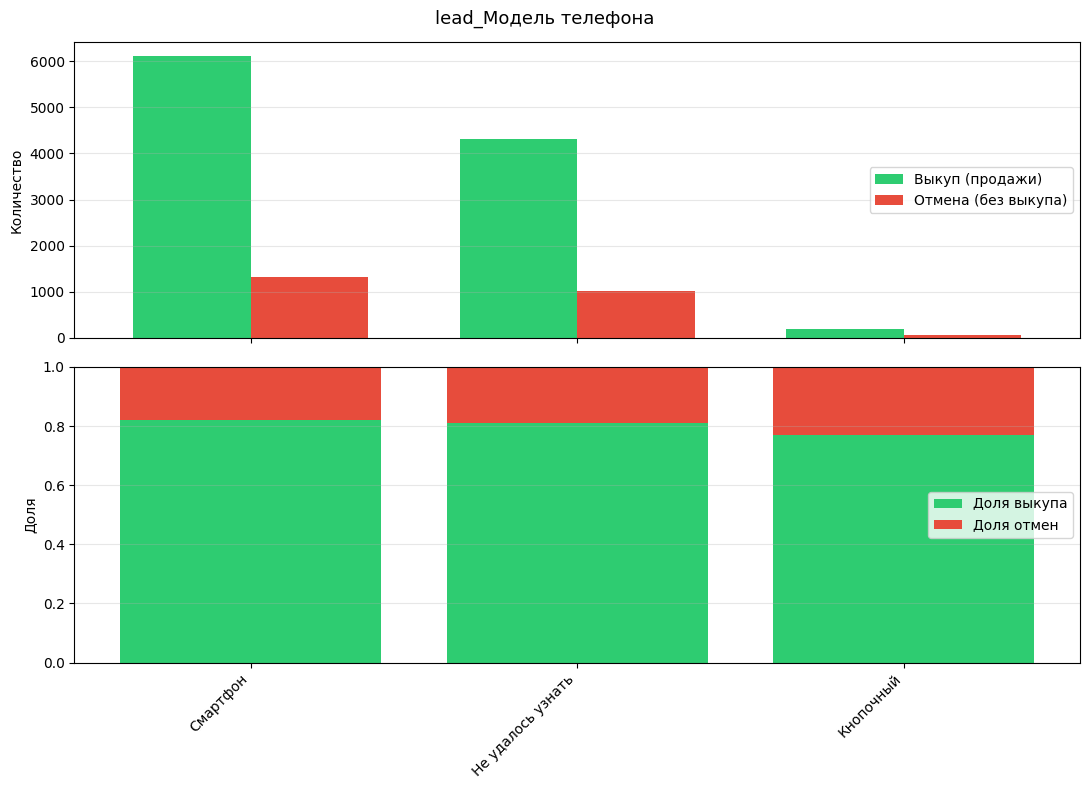


lead_будущие покупки
                      выкуп  без_выкупа  всего  buyout_rate
lead_будущие покупки                                       
не известно            6741        1564   8305        0.812
унив повязка            825         219   1044        0.790
матрас                  728         161    889        0.819
подушка                 578         141    719        0.804
сапоги                  113          22    135        0.837
шлем                     87          16    103        0.845
одеяло                   55          15     70        0.786
жилет                    55          10     65        0.846
шорты                    35           8     43        0.814
капсула                  33           9     42        0.786


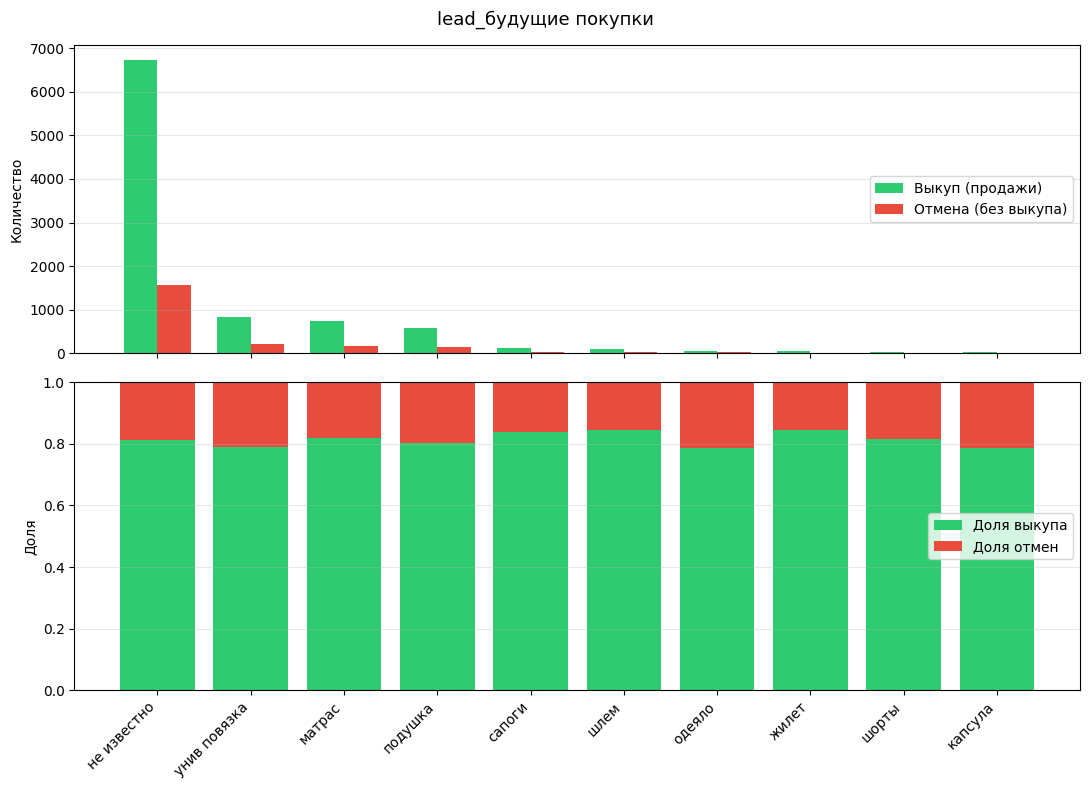


lead_Проблема
                                 выкуп  без_выкупа  всего  buyout_rate
lead_Проблема                                                         
Суставы и позвоночник             6744        1275   8019        0.841
Варикоз                           4115         998   5113        0.805
Сердечно-сосудистые заболевания    969         216   1185        0.818
Бессоница                          929         155   1084        0.857
Головные боли                      534          91    625        0.854
Отеки                              304          86    390        0.779
Зрительная система                 328          49    377        0.870
Давление                           220          55    275        0.800
Инсульт                            177          51    228        0.776
Боли и тяжесть в ногах             186          38    224        0.830
Женские проблемы                    80           5     85        0.941
Ушибы. травмы, отеки, ожоги         66          15     81     

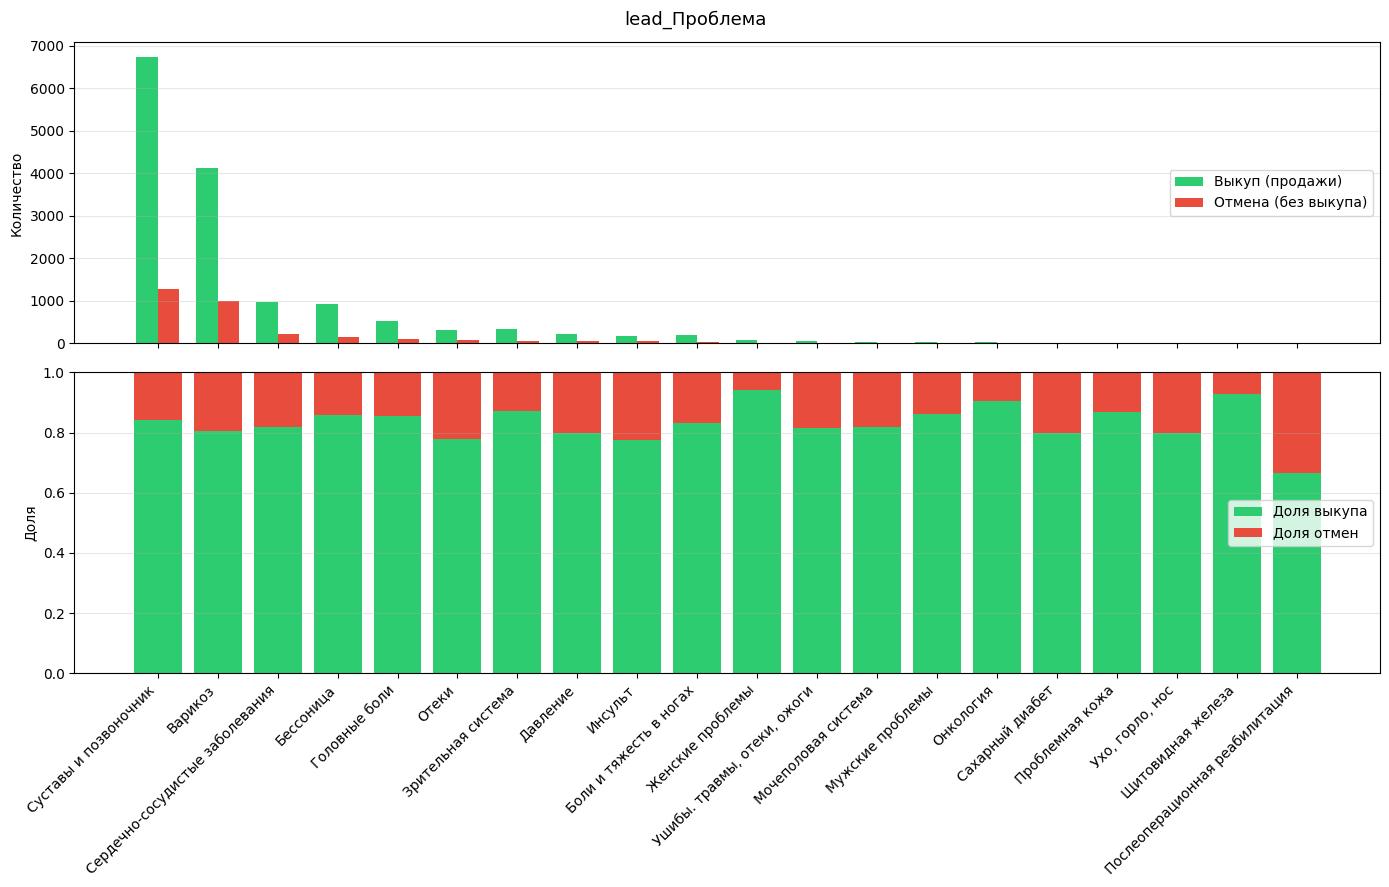

In [5]:
# Категориальные признаки для EDA
CAT_EDA = [
    'lead_Служба доставки',
    'lead_Вид оплаты',
    'lead_Компания Отправитель',
    'lead_Тариф Доставки',
    'lead_Квалификация лида',
    'lead_Категория и варианты выбора',
    'lead_Модель телефона',
    'lead_будущие покупки',
    'lead_Проблема',
]

for col in CAT_EDA:
    if col not in df.columns:
        print(f'{col}: отсутствует в данных, пропуск')
        continue
    n_unique = df[col].nunique()
    top_n = 20 if n_unique > 20 else None
    plot_feature_two_panel(df, col, col, top_n=top_n)

### Наблюдения по категориальным признакам

- **Вид оплаты:** предоплата (`Предоплата`) резко повышает buyout rate (97%+) — клиент уже заплатил. Наложенный платёж — основная зона риска.
- **Служба доставки:** СДЭК до ПВЗ показывает выше buyout, чем Почта России.
- **Квалификация лида:** NaN-значения показывают buyout выше, чем некоторые квалифицированные категории — это важный сигнал, NaN нужно сохранить как отдельный класс.
- **Модель телефона:** тип устройства (смартфон vs кнопочный) коррелирует с buyout.

## 4. EDA — Числовые признаки

Для числовых признаков строим:
- **Верхняя панель:** наложенные гистограммы выкупов и отказов
- **Нижняя панель:** доля выкупа в каждом бине (stacked 100% bars)


lead_price
                        выкуп  без_выкупа  всего
lead_price                                      
[0, 1333]                 110          33    143
[1333, 2667]              285          32    317
[2667, 4000]             1454         230   1684
[4000, 5333]              781         127    908
[5333, 6667]             1365         231   1596
[6667, 8000]             2308         449   2757
[8000, 9333]             1696         418   2114
[9333, 1.067e+04]         985         215   1200
[1.067e+04, 1.2e+04]      667         104    771
[1.2e+04, 1.333e+04]     1021         221   1242
[1.333e+04, 1.467e+04]    790         207    997
[1.467e+04, 1.6e+04]      611         142    753
[1.6e+04, 1.733e+04]      562         169    731
[1.733e+04, 1.867e+04]    472         145    617
[1.867e+04, 2e+04]        283          79    362
[2e+04, 2.133e+04]        269          54    323
[2.133e+04, 2.267e+04]    262          48    310
[2.267e+04, 2.4e+04]      139          31    170
[2.4e+04

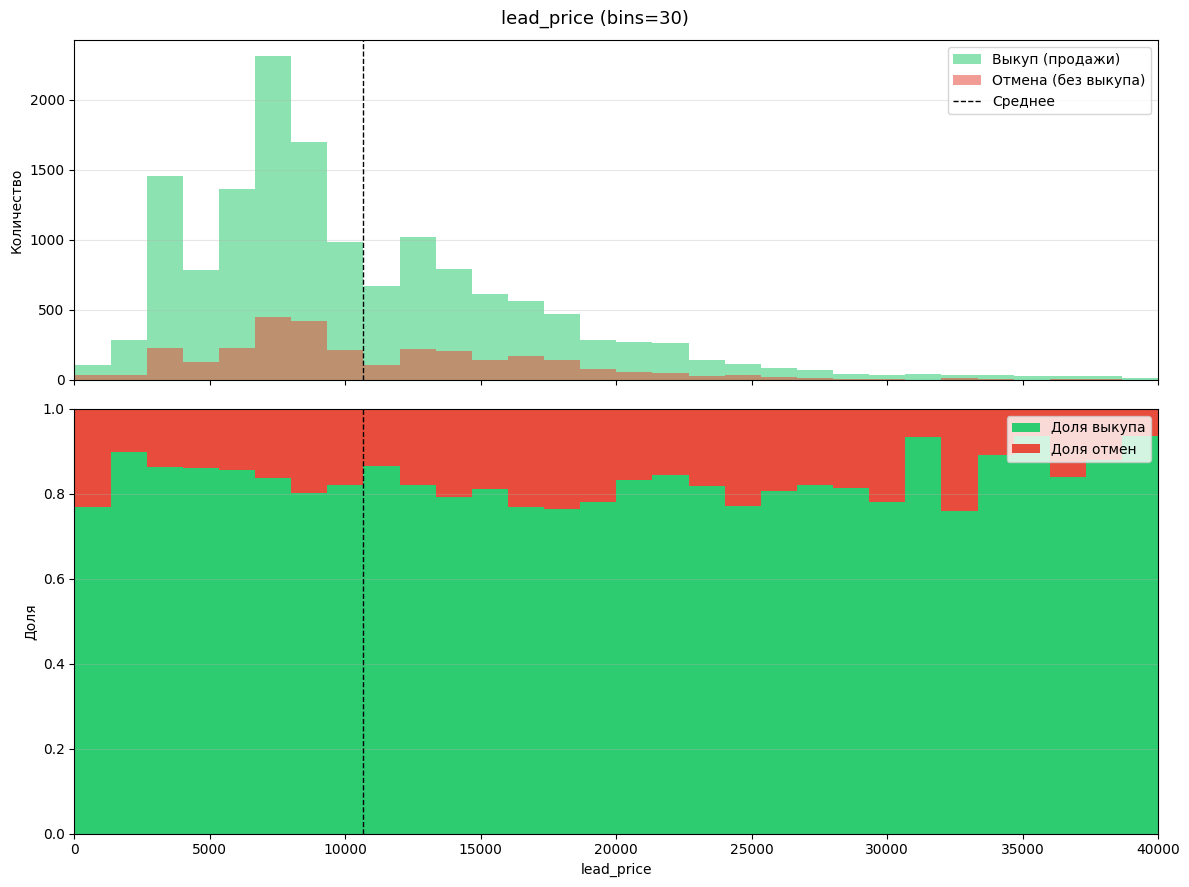


lead_Стоимость доставки
                         выкуп  без_выкупа  всего
lead_Стоимость доставки                          
[346, 424.9]                 2           2      4
[424.9, 503.7]               2           1      3
[503.7, 582.5]               1           0      1
[582.5, 661.4]               1           1      2
[661.4, 740.2]               5           0      5
[740.2, 819.1]               1           0      1
[819.1, 897.9]               2           0      2
[897.9, 976.8]               3           0      3
[976.8, 1056]                1           0      1
[1056, 1134]                 0           0      0
[1134, 1213]                 2           0      2
[1213, 1292]                 3           1      4
[1292, 1371]                 1           0      1
[1371, 1450]                 0           2      2
[1450, 1529]                 2           0      2
[1529, 1608]                 0           0      0
[1608, 1686]                 1           0      1
[1686, 1765]             

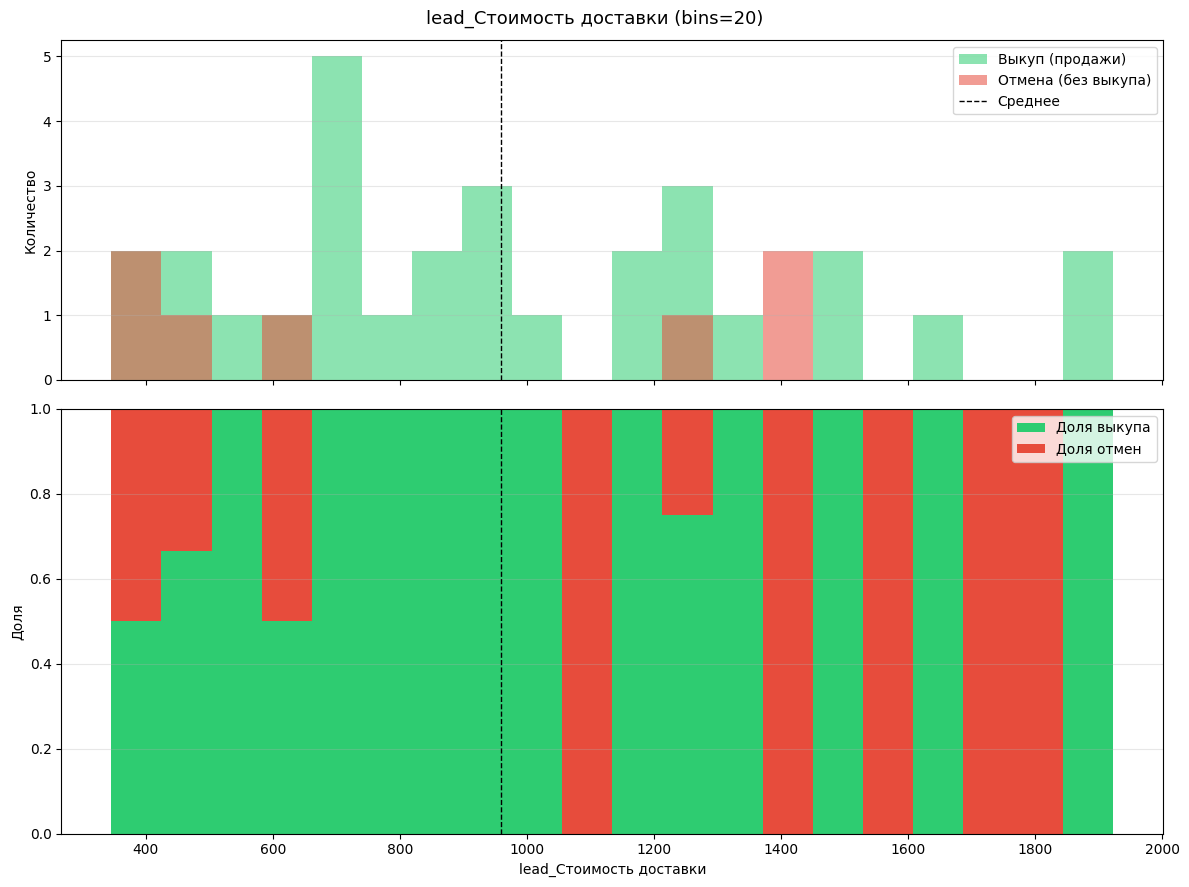


contact_Число сделок
                      выкуп  без_выкупа  всего
contact_Число сделок                          
[0, 1]                    9           0      9
[1, 2]                 9963         233  10196
[2, 3]                 1855          63   1918
[3, 4]                  627          18    645
[4, 5]                  368           4    372
[5, 6]                  212           4    216
[6, 7]                  125           2    127
[7, 8]                  194           2    196


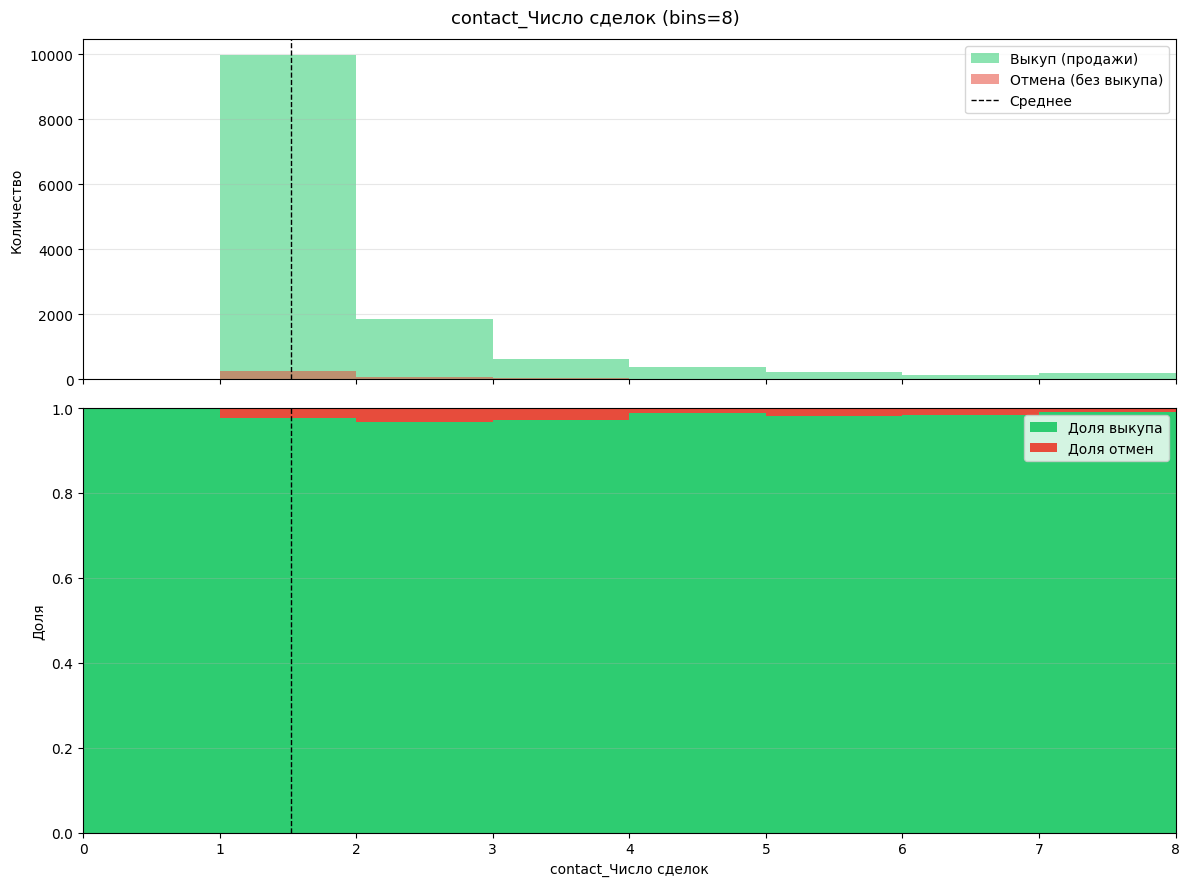


lead_Скидка
             выкуп  без_выкупа  всего
lead_Скидка                          
[0, 5]          14           5     19
[5, 10]        138          10    148
[10, 15]       950         271   1221
[15, 20]       742          72    814
[20, 25]        84          17    101
[25, 30]        83          15     98
[30, 35]       103          10    113
[35, 40]        30           1     31


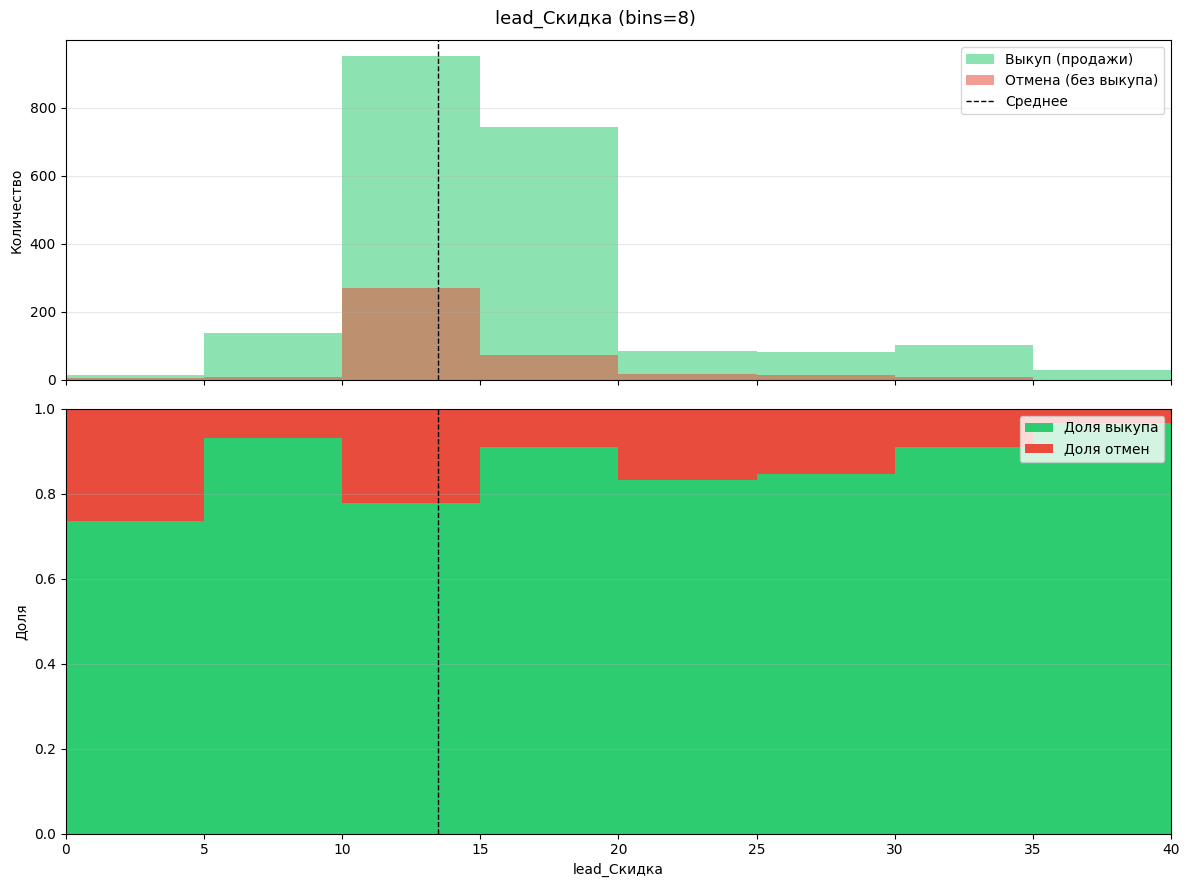

In [6]:
def plot_numeric_buyout_by_hist(df, col, title=None, bins=30, xlim=None):
    """Числовой признак: верх — наложенные гистограммы, низ — доля выкупа по бинам."""
    if title is None:
        title = col
    s = pd.to_numeric(df[col], errors='coerce')
    mask = s.notna()
    if not mask.any():
        print(f'\n{col}: нет данных (всё NaN), пропуск\n')
        return
    vals = s[mask].to_numpy(dtype=float)
    buy = df.loc[mask, 'buyout_flag'].astype(bool).to_numpy()

    hist_range = None
    lo_r = hi_r = None
    if xlim is not None:
        lo_r, hi_r = xlim[0], xlim[1]
        if lo_r is None: lo_r = float(np.min(vals))
        if hi_r is None: hi_r = float(np.max(vals))
        win = (vals >= lo_r) & (vals <= hi_r)
        vals_f, buy_f = vals[win], buy[win]
        if vals_f.size == 0:
            print(f'\n{col}: нет точек в xlim, пропуск\n')
            return
        hist_range = (lo_r, hi_r)
    else:
        vals_f, buy_f = vals, buy

    _, edges = np.histogram(vals_f, bins=bins, range=hist_range) if hist_range else np.histogram(vals_f, bins=bins)
    nbins = len(edges) - 1
    idx = np.clip(np.searchsorted(edges, vals_f, side='right') - 1, 0, nbins - 1)

    n_tot = np.bincount(idx, minlength=nbins)[:nbins].astype(int)
    n_buy_arr = np.bincount(idx[buy_f], minlength=nbins)[:nbins].astype(int)
    n_cancel_arr = n_tot - n_buy_arr
    rate = np.divide(n_buy_arr.astype(float), n_tot, out=np.zeros(nbins), where=n_tot > 0)

    left = edges[:-1]
    widths = np.diff(edges)
    mean_v = float(np.mean(vals_f))

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 9), sharex=True,
                                    gridspec_kw={'height_ratios': [1, 1.25]})
    fig.suptitle(f'{title} (bins={nbins})', fontsize=13)

    ax1.hist(vals_f[buy_f], bins=edges, color=GREEN, alpha=0.55,
             label='Выкуп (продажи)', edgecolor='none')
    ax1.hist(vals_f[~buy_f], bins=edges, color=RED, alpha=0.55,
             label='Отмена (без выкупа)', edgecolor='none')
    ax1.axvline(mean_v, color='black', linestyle='--', linewidth=1, label='Среднее', zorder=5)
    ax1.set_ylabel('Количество')
    ax1.legend(loc='upper right')
    ax1.grid(axis='y', alpha=0.3)

    ax2.bar(left, rate, width=widths, align='edge', color=GREEN,
            label='Доля выкупа', edgecolor='none', linewidth=0)
    ax2.bar(left, 1.0 - rate, width=widths, bottom=rate, align='edge',
            color=RED, label='Доля отмен', edgecolor='none', linewidth=0)
    ax2.set_ylabel('Доля')
    ax2.set_xlabel(col)
    ax2.set_ylim(0, 1)
    ax2.legend(loc='upper right')
    ax2.grid(axis='y', alpha=0.3)
    ax2.axvline(mean_v, color='black', linestyle='--', linewidth=1, zorder=5)

    if hist_range is not None:
        ax2.set_xlim(lo_r, hi_r)

    bin_lbl = [f'[{left[i]:.4g}, {edges[i+1]:.4g}]' for i in range(nbins)]
    tbl = pd.DataFrame({'выкуп': n_buy_arr, 'без_выкупа': n_cancel_arr, 'всего': n_tot}, index=bin_lbl)
    tbl.index.name = col
    print(f"\n{'=' * 60}\n{title}\n{'=' * 60}")
    print(tbl.to_string())

    plt.tight_layout(); plt.show()


NUM_EDA = {
    'lead_price':              {'bins': 30, 'xlim': (0, 40_000)},
    'lead_Стоимость доставки': {'bins': 20, 'xlim': None},
    'contact_Число сделок':    {'bins': 8,  'xlim': (0, 8)},
    'lead_Скидка':             {'bins': 8,  'xlim': (0, 40)},
}

for col, params in NUM_EDA.items():
    if col not in df.columns:
        print(f'{col}: отсутствует, пропуск')
        continue
    plot_numeric_buyout_by_hist(df, col, **params)

## 5. Feature Engineering

На основе EDA создаём признаки для модели новых клиентов:

**NaN как информативный класс:** для ряда категорий NaN показывает buyout rate выше, чем заполненные значения (например, NaN в `lead_Квалификация лида` → 86% buyout). Такие NaN заменяем на `'__NaN__'` — отдельный класс.

**Ценовые бины:** `lead_price` имеет U-образную зависимость с buyout (дешёвые и дорогие заказы выкупают чаще, средние — реже). Линейная модель не может это уловить, поэтому разбиваем цену на бины.

**Временные признаки:** месяц, день недели, квартал продажи — сезонность влияет на buyout.

**Бинарные признаки:** наличие размеров товара, скидки, платный трафик, задержка между заявкой и продажей.

**Гео-признаки:** адрес клиента матчится с базой городов России для извлечения стандартизированного города и региона.

**Агрегатные признаки:** количество сделок менеджера (характеризует опыт менеджера).

In [7]:
# NaN как отдельный класс — для признаков, где NaN несёт информацию
for col in ['lead_Квалификация лида', 'lead_Категория и варианты выбора',
            'lead_Тариф Доставки', 'lead_будущие покупки', 'lead_Модель телефона']:
    if col in df.columns:
        df[col] = df[col].fillna('__NaN__')

# NaN → 'unknown' — для признаков, где NaN = отсутствие данных
for col in ['lead_Служба доставки', 'lead_Вид оплаты', 'lead_Проблема', 'lead_Компания Отправитель']:
    if col in df.columns:
        df[col] = df[col].fillna('unknown')

print('NaN-обработка завершена')
print(f"Строк: {len(df)}")

NaN-обработка завершена
Строк: 17966


In [8]:
# Временные признаки
df['sale_month'] = df['sale_date'].dt.month.astype(str)
df['sale_weekday'] = df['sale_date'].dt.dayofweek.astype(str)
df['sale_quarter'] = ((df['sale_date'].dt.month - 1) // 3 + 1).astype(str)
df['sale_stale'] = ((df['sale_ts'] - df['lead_created_at']) / 86400 > 1).astype(int)

# Бинарные признаки
df['has_dimensions'] = df['lead_Вес (грамм)*'].notna().astype(int) if 'lead_Вес (грамм)*' in df.columns else 0
df['has_discount'] = df['lead_Скидка'].notna().astype(int) if 'lead_Скидка' in df.columns else 0

paid_channels = ['cpc', 'cpc__rt_view-yes_lead-no_all', 'Bloger', 'article_direct', 'cpm']
df['is_paid_traffic'] = df['lead_utm_medium'].isin(paid_channels).astype(int) if 'lead_utm_medium' in df.columns else 0

# Количество товаров в заказе
def count_items(comp):
    if pd.isna(comp) or not isinstance(comp, str): return 0
    lines = [l.strip() for l in comp.replace(';', '\n').split('\n') if l.strip()]
    items = [l for l in lines if 'доставк' not in l.lower()]
    return max(len(items), 1) if items else 0

df['cart_n_items'] = df['lead_Состав заказа'].apply(count_items) if 'lead_Состав заказа' in df.columns else 0

# Ценовые бины (U-образная зависимость с buyout)
bins = [0, 3000, 5000, 8000, 15000, 25000, np.inf]
labels = ['0-3k', '3-5k', '5-8k', '8-15k', '15-25k', '25k+']
df['price_bin'] = pd.cut(df['lead_price'], bins=bins, labels=labels).astype(str)
df.loc[df['lead_price'].isna(), 'price_bin'] = 'unknown'

# Стоимость доставки
if 'lead_Стоимость доставки' in df.columns:
    df['lead_Стоимость доставки'] = df['lead_Стоимость доставки'].fillna(0)
else:
    df['lead_Стоимость доставки'] = 0

# ID → строки
for col in ['lead_pipeline_id', 'lead_group_id', 'lead_responsible_user_id']:
    if col in df.columns:
        df[col] = df[col].astype(str)

print('Temporal, binary, price features созданы')

Temporal, binary, price features созданы


In [9]:
# Гео-матчинг: сопоставляем адрес клиента с базой городов России
with open('russia-cities.json', encoding='utf-8') as f:
    russia_cities_raw = json.load(f)

russia_cities = [{'name': c['name'], 'region': c['region']['fullname']}
                 for c in russia_cities_raw if c.get('name')]
russia_cities.extend([
    {'name': 'Ялта', 'region': 'Республика Крым'},
    {'name': 'Керчь', 'region': 'Республика Крым'},
    {'name': 'Севастополь', 'region': 'Севастополь'},
    {'name': 'Феодосия', 'region': 'Республика Крым'},
    {'name': 'Красноперекопск', 'region': 'Республика Крым'},
    {'name': 'Евпатория', 'region': 'Республика Крым'},
    {'name': 'Алушта', 'region': 'Республика Крым'},
])

_norm = lambda s: str(s).lower().replace('ё', 'е')
sorted_cities = sorted(russia_cities, key=lambda x: len(x['name']), reverse=True)

def geo_match_series(addresses):
    cities_out, regions_out = [], []
    for addr in addresses.values:
        if pd.isna(addr):
            cities_out.append('__unknown__'); regions_out.append('__unknown__'); continue
        addr_n = _norm(addr)
        found = False
        for c in sorted_cities:
            if _norm(c['name']) in addr_n:
                cities_out.append(c['name']); regions_out.append(c['region']); found = True; break
        if not found:
            cities_out.append('__unknown__'); regions_out.append('__unknown__')
    return cities_out, regions_out

cities, regions = geo_match_series(df['contact_Город'])
df['city_clean'] = cities
df['contact_region'] = regions

n_unknown = (df['city_clean'] == '__unknown__').sum()
print(f'Гео-матчинг завершён: {len(russia_cities)} городов в базе')
print(f'Unknown городов: {n_unknown} ({n_unknown/len(df)*100:.1f}%)')

Гео-матчинг завершён: 1109 городов в базе
Unknown городов: 1504 (8.4%)


In [10]:
# Агрегатные признаки
# Количество сделок менеджера (не использует target — нет утечки)
df['manager_deal_count'] = df.groupby('lead_responsible_user_id')['lead_responsible_user_id'].transform('count')

print(f'manager_deal_count: min={df["manager_deal_count"].min()}, '
      f'max={df["manager_deal_count"].max()}, '
      f'mean={df["manager_deal_count"].mean():.0f}')

# EDA: buyout rate по группам, менеджерам, службам доставки (для визуализации)
print('\nBuyout rate по lead_group_id:')
print(df.groupby('lead_group_id')['buyout_flag'].agg(['mean', 'count']).sort_values('count', ascending=False).to_string(float_format='%.3f'))

print('\nBuyout rate по lead_Служба доставки (top-10):')
print(df.groupby('lead_Служба доставки')['buyout_flag'].agg(['mean', 'count']).sort_values('count', ascending=False).head(10).to_string(float_format='%.3f'))

manager_deal_count: min=1, max=4232, mean=2236

Buyout rate по lead_group_id:
               mean  count
lead_group_id             
700242        0.805   5683
546538        0.833   5586
0             0.849   4238
700246        0.819   1758
708650        0.883    701

Buyout rate по lead_Служба доставки (top-10):
                      mean  count
lead_Служба доставки             
СДЭК до ПВЗ          0.847  12588
Почта                0.765   2922
СДЭК до Двери        0.811   2416
Самовывоз            0.913     23
unknown              0.133     15
Курьер ЕМС           0.500      2



sale_quarter
              выкуп  без_выкупа  всего  buyout_rate
sale_quarter                                       
1              5218        1051   6269        0.832
2              3275         541   3816        0.858
3              3347         693   4040        0.828
4              3042         799   3841        0.792


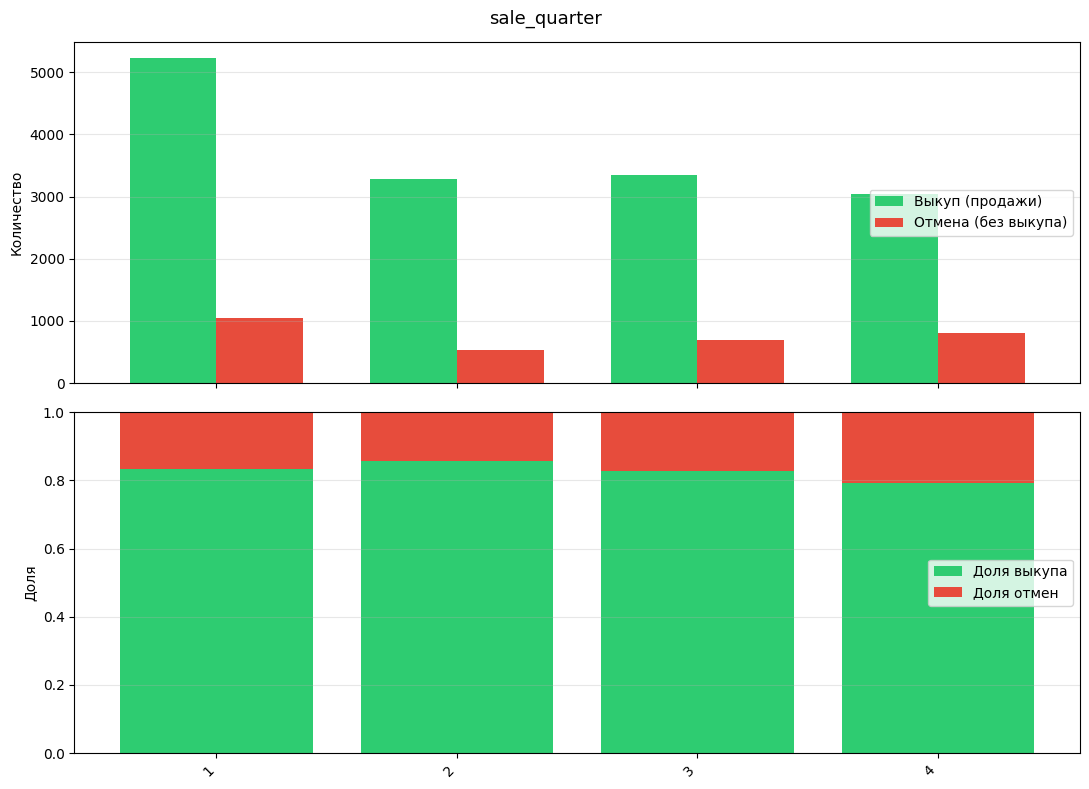


sale_month
            выкуп  без_выкупа  всего  buyout_rate
sale_month                                       
1            1149         278   1427        0.805
2            1321         328   1649        0.801
3            2748         445   3193        0.861
4            1139         172   1311        0.869
5            1157         195   1352        0.856
6             979         174   1153        0.849
7            1100         182   1282        0.858
8            1133         278   1411        0.803
9            1114         233   1347        0.827
10           1223         337   1560        0.784
11            938         267   1205        0.778
12            881         195   1076        0.819


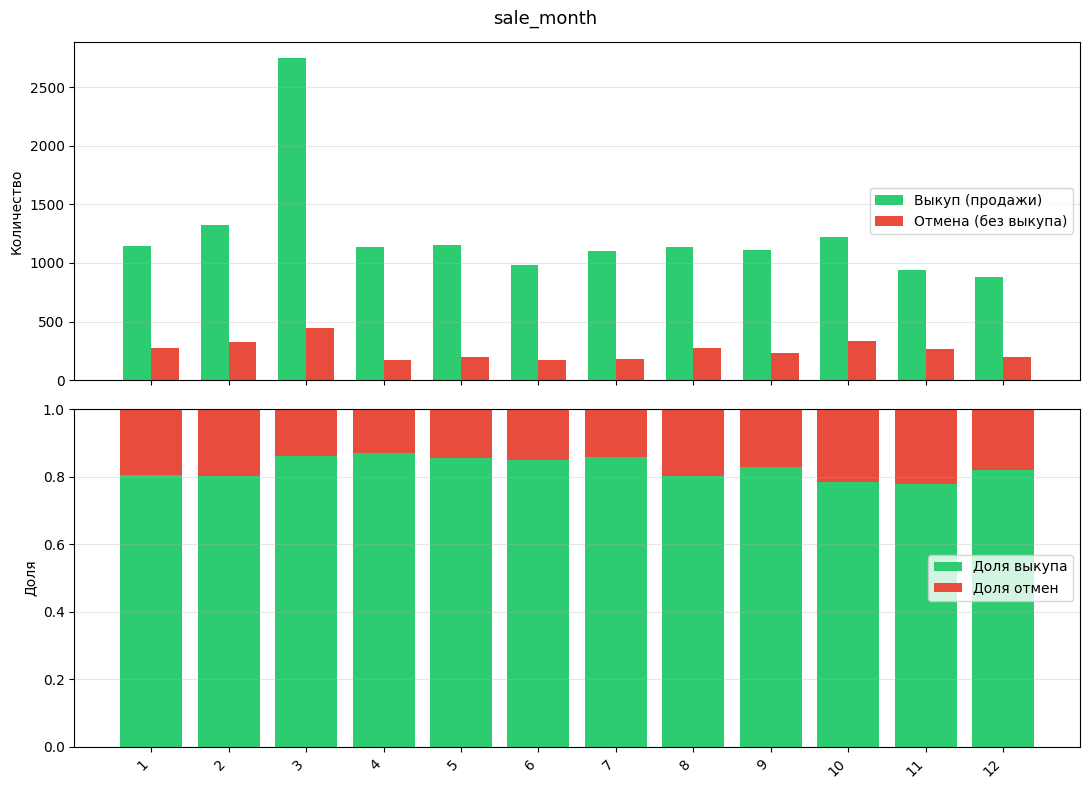


sale_weekday
              выкуп  без_выкупа  всего  buyout_rate
sale_weekday                                       
0              2211         427   2638        0.838
1              2225         397   2622        0.849
2              2214         401   2615        0.847
3              2139         447   2586        0.827
4              2133         457   2590        0.824
5              2060         494   2554        0.807
6              1900         461   2361        0.805


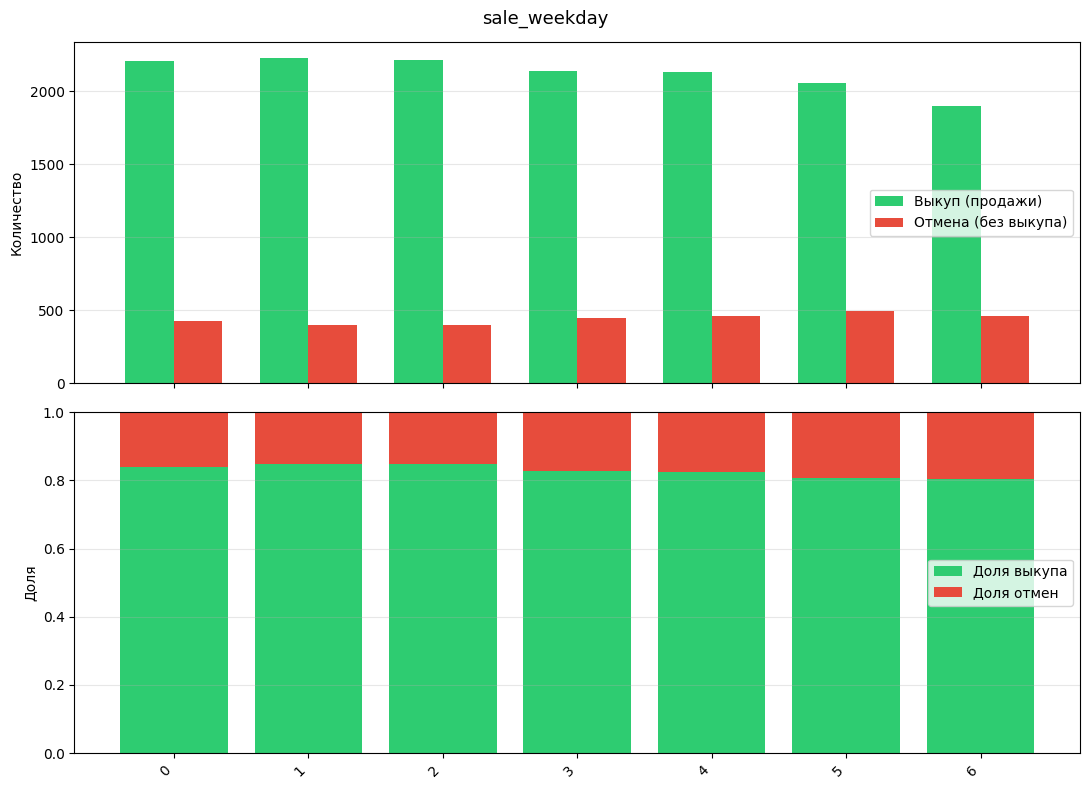


price_bin
           выкуп  без_выкупа  всего  buyout_rate
price_bin                                       
8-15k       5293        1202   6495        0.815
5-8k        3879         720   4599        0.843
15-25k      2540         655   3195        0.795
3-5k        1826         285   2111        0.865
25k+         731         122    853        0.857
0-3k         579          78    657        0.881
nan           34          22     56        0.607


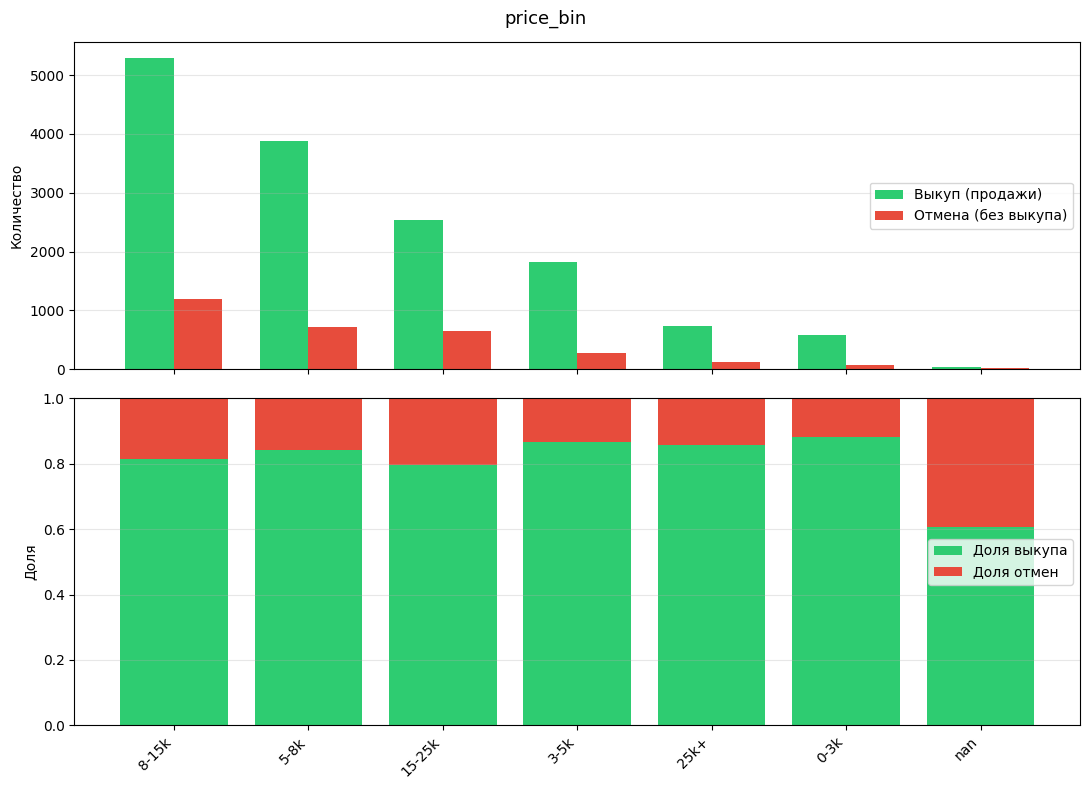


cart_n_items
              выкуп  без_выкупа  всего
cart_n_items                          
[0, 1]           31          19     50
[1, 2]            1           0      1
[2, 3]            0           0      0
[3, 4]            0           0      0
[4, 5]          174          33    207
[5, 6]            0           0      0
[6, 7]            0           0      0
[7, 8]         6528        1348   7876
[8, 9]          124          13    137
[9, 10]           0           0      0


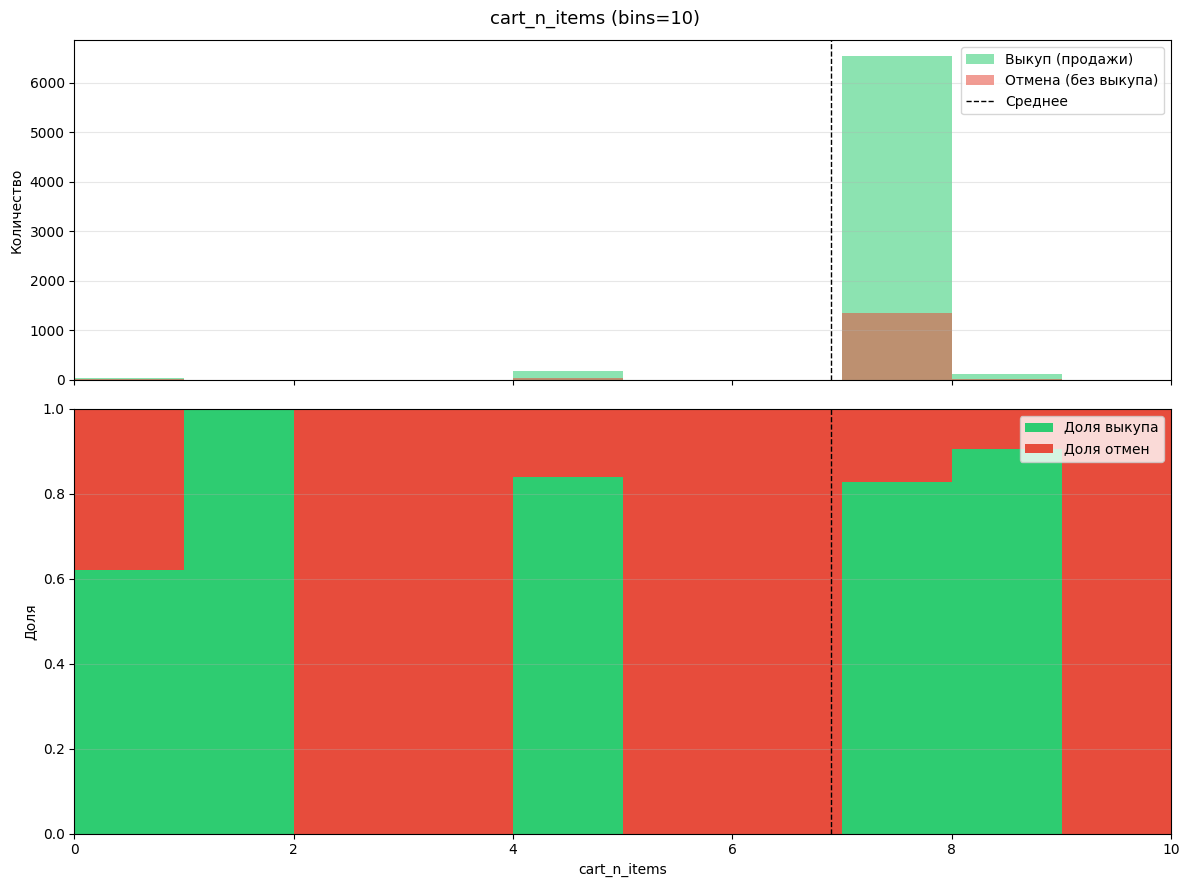


manager_deal_count
                    выкуп  без_выкупа  всего
manager_deal_count                          
[0, 211.6]            955         260   1215
[211.6, 423.2]        713         154    867
[423.2, 634.8]          0           0      0
[634.8, 846.4]       2520         506   3026
[846.4, 1058]           0           0      0
[1058, 1270]            0           0      0
[1270, 1481]            0           0      0
[1481, 1693]         1313         364   1677
[1693, 1904]         1436         319   1755
[1904, 2116]            0           0      0
[2116, 2328]         2026         301   2327
[2328, 2539]            0           0      0
[2539, 2751]            0           0      0
[2751, 2962]         2324         543   2867
[2962, 3174]            0           0      0
[3174, 3386]            0           0      0
[3386, 3597]            0           0      0
[3597, 3809]            0           0      0
[3809, 4020]            0           0      0
[4020, 4232]         3595         6

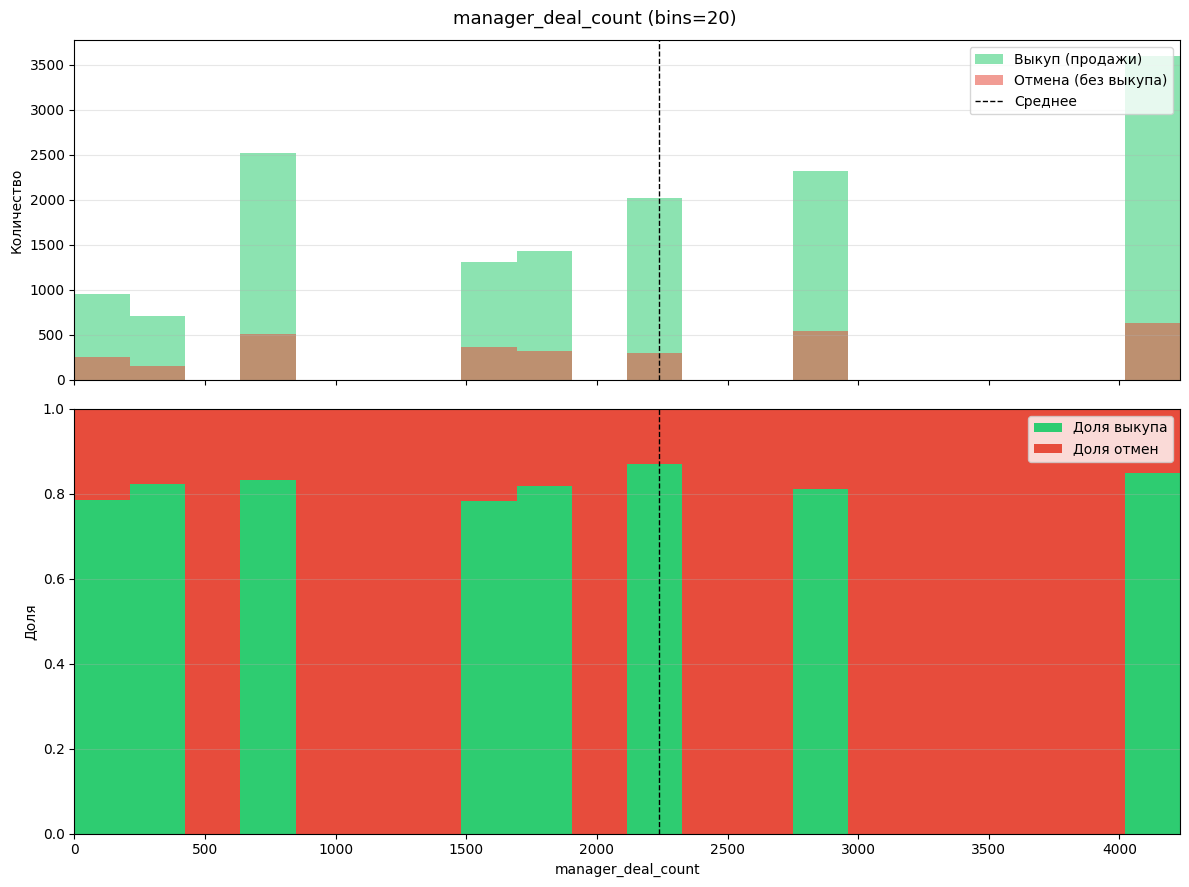

In [11]:
# EDA на инженерных признаках
for col in ['sale_quarter', 'sale_month', 'sale_weekday', 'price_bin']:
    plot_feature_two_panel(df, col, col)

plot_numeric_buyout_by_hist(df, 'cart_n_items', bins=10, xlim=(0, 10))
plot_numeric_buyout_by_hist(df, 'manager_deal_count', bins=20, xlim=(0, df['manager_deal_count'].quantile(0.99)))

## 6. Определение признаков для модели

Признаки разделены на группы по типу кодирования:
- **cat_cols** — one-hot encoding (low/medium cardinality)
- **num_cols** — StandardScaler
- **bin_cols** — без преобразования (уже 0/1)
- **geo_cols** — target encoding (high cardinality geo features)
- **te_cat_cols** — target encoding (high cardinality categoricals + группы)

In [12]:
cat_cols = [
    'lead_pipeline_id',
    'lead_Вид оплаты', 'lead_Компания Отправитель',
    'lead_Тариф Доставки', 'lead_Квалификация лида',
    'lead_Категория и варианты выбора',
    'lead_Модель телефона',
    'sale_month', 'sale_weekday', 'sale_quarter',
    'price_bin',
]

num_cols = ['lead_price', 'cart_n_items', 'lead_Стоимость доставки', 'manager_deal_count']

bin_cols = ['has_dimensions', 'has_discount', 'is_paid_traffic', 'sale_stale']

geo_cols = ['city_clean', 'contact_region']

te_cat_cols = [
    'lead_responsible_user_id', 'lead_Проблема', 'lead_будущие покупки',
    'lead_group_id', 'lead_Служба доставки',
]

all_feature_cols = cat_cols + num_cols + bin_cols + geo_cols + te_cat_cols

print(f'cat_cols ({len(cat_cols)}): {cat_cols}')
print(f'num_cols ({len(num_cols)}): {num_cols}')
print(f'bin_cols ({len(bin_cols)}): {bin_cols}')
print(f'geo_cols ({len(geo_cols)}): {geo_cols}')
print(f'te_cat_cols ({len(te_cat_cols)}): {te_cat_cols}')
print(f'\nВсего признаков: {len(all_feature_cols)}')

cat_cols (11): ['lead_pipeline_id', 'lead_Вид оплаты', 'lead_Компания Отправитель', 'lead_Тариф Доставки', 'lead_Квалификация лида', 'lead_Категория и варианты выбора', 'lead_Модель телефона', 'sale_month', 'sale_weekday', 'sale_quarter', 'price_bin']
num_cols (4): ['lead_price', 'cart_n_items', 'lead_Стоимость доставки', 'manager_deal_count']
bin_cols (4): ['has_dimensions', 'has_discount', 'is_paid_traffic', 'sale_stale']
geo_cols (2): ['city_clean', 'contact_region']
te_cat_cols (5): ['lead_responsible_user_id', 'lead_Проблема', 'lead_будущие покупки', 'lead_group_id', 'lead_Служба доставки']

Всего признаков: 26


## 7. Разделение на выборки

Стратегия разбиения:
1. Сначала разделяем весь датасет на **новых** и **повторных** клиентов
2. Внутри каждой группы делаем стратифицированное разбиение **60% train / 20% test / 20% val**

Это гарантирует, что пропорция buyout сохраняется в каждой подвыборке, и каждая модель обучается на данных своего типа клиентов.

Дополнительно формируем `train_df` (объединение new_train + ret_train) — он нужен для модели повторных клиентов, которая обучается на **всех** данных для понимания контраста между 0 и >=1 заказов.

In [13]:
is_new = df['contact_Число сделок'].isna() | (df['contact_Число сделок'] < 1)
df_new = df[is_new].copy()
df_ret = df[~is_new].copy()

print(f'Новые клиенты: {len(df_new)}, buyout: {df_new["buyout_flag"].mean():.4f}')
print(f'Повторные:     {len(df_ret)}, buyout: {df_ret["buyout_flag"].mean():.4f}')

# 60/20/20 внутри новых клиентов
new_train, new_temp = train_test_split(
    df_new, test_size=0.4, random_state=42, stratify=df_new['buyout_flag'])
new_val, new_test = train_test_split(
    new_temp, test_size=0.5, random_state=42, stratify=new_temp['buyout_flag'])

# 60/20/20 внутри повторных клиентов
ret_train, ret_temp = train_test_split(
    df_ret, test_size=0.4, random_state=42, stratify=df_ret['buyout_flag'])
ret_val, ret_test = train_test_split(
    ret_temp, test_size=0.5, random_state=42, stratify=ret_temp['buyout_flag'])

# Объединённые сплиты (для модели повторных клиентов)
train_df = pd.concat([new_train, ret_train], ignore_index=True)
test_df = pd.concat([new_test, ret_test], ignore_index=True)
val_df = pd.concat([new_val, ret_val], ignore_index=True)

print(f'\nНовые клиенты:')
print(f'  Train: {len(new_train)}, buyout: {new_train["buyout_flag"].mean():.4f}')
print(f'  Test:  {len(new_test)}, buyout: {new_test["buyout_flag"].mean():.4f}')
print(f'  Val:   {len(new_val)}, buyout: {new_val["buyout_flag"].mean():.4f}')

print(f'\nПовторные клиенты:')
print(f'  Train: {len(ret_train)}, buyout: {ret_train["buyout_flag"].mean():.4f}')
print(f'  Test:  {len(ret_test)}, buyout: {ret_test["buyout_flag"].mean():.4f}')
print(f'  Val:   {len(ret_val)}, buyout: {ret_val["buyout_flag"].mean():.4f}')

print(f'\nОбъединённые:')
print(f'  Train: {len(train_df)}, Test: {len(test_df)}, Val: {len(val_df)}')

Новые клиенты: 4079, buyout: 0.3248
Повторные:     13887, buyout: 0.9762

Новые клиенты:
  Train: 2447, buyout: 0.3249
  Test:  816, buyout: 0.3248
  Val:   816, buyout: 0.3248

Повторные клиенты:
  Train: 8332, buyout: 0.9762
  Test:  2778, buyout: 0.9762
  Val:   2777, buyout: 0.9762

Объединённые:
  Train: 10779, Test: 3594, Val: 3593


In [14]:
# Убираем строки с NaN в lead_price (нужен для модели новых клиентов)
for name, data in [('new_train', new_train), ('new_test', new_test), ('new_val', new_val)]:
    na_count = data['lead_price'].isna().sum()
    if na_count > 0:
        print(f'{name}: удалено {na_count} строк с NaN в lead_price')

new_train = new_train.dropna(subset=['lead_price']).copy()
new_test = new_test.dropna(subset=['lead_price']).copy()
new_val = new_val.dropna(subset=['lead_price']).copy()

# Проверяем наличие всех feature-столбцов
missing = [c for c in all_feature_cols if c not in new_train.columns]
if missing:
    print(f'ВНИМАНИЕ: отсутствуют столбцы: {missing}')
else:
    print(f'Все {len(all_feature_cols)} признаков присутствуют')

print(f'\nФинальные размеры (новые клиенты):')
print(f'  Train: {len(new_train)}, Test: {len(new_test)}, Val: {len(new_val)}')

Все 26 признаков присутствуют

Финальные размеры (новые клиенты):
  Train: 2447, Test: 816, Val: 816


## 8. Сохранение подготовленных данных

Сохраняем все подвыборки, списки признаков и справочник городов в единый файл `processed_data.pkl`. Ноутбук обучения (`02_model_training.ipynb`) загрузит эти данные и построит модели.

In [15]:
artifacts = {
    'new_train': new_train, 'new_test': new_test, 'new_val': new_val,
    'ret_train': ret_train, 'ret_test': ret_test, 'ret_val': ret_val,
    'train_df': train_df, 'test_df': test_df, 'val_df': val_df,
    'cat_cols': cat_cols, 'num_cols': num_cols, 'bin_cols': bin_cols,
    'geo_cols': geo_cols, 'te_cat_cols': te_cat_cols,
    'all_feature_cols': all_feature_cols,
    'russia_cities': russia_cities,
}

with open('processed_data.pkl', 'wb') as f:
    pickle.dump(artifacts, f)

size_kb = os.path.getsize('processed_data.pkl') / 1024
print(f'Сохранено processed_data.pkl ({size_kb:.0f} KB)')
print(f'\nСодержимое:')
for key, val in artifacts.items():
    if isinstance(val, pd.DataFrame):
        print(f'  {key}: DataFrame ({len(val)} строк)')
    elif isinstance(val, list):
        print(f'  {key}: list ({len(val)} элементов)')

print('\nДанные готовы для обучения → 02_model_training.ipynb')

Сохранено processed_data.pkl (63298 KB)

Содержимое:
  new_train: DataFrame (2447 строк)
  new_test: DataFrame (816 строк)
  new_val: DataFrame (816 строк)
  ret_train: DataFrame (8332 строк)
  ret_test: DataFrame (2778 строк)
  ret_val: DataFrame (2777 строк)
  train_df: DataFrame (10779 строк)
  test_df: DataFrame (3594 строк)
  val_df: DataFrame (3593 строк)
  cat_cols: list (11 элементов)
  num_cols: list (4 элементов)
  bin_cols: list (4 элементов)
  geo_cols: list (2 элементов)
  te_cat_cols: list (5 элементов)
  all_feature_cols: list (26 элементов)
  russia_cities: list (1109 элементов)

Данные готовы для обучения → 02_model_training.ipynb
